# DSA 210
## Can Google Searches Predict Youth Unemployment in Turkey?

This notebook covers data collection, exploratory data analysis (EDA), and hypothesis testing.

**Data sources:**
- TÜİK Labour Force Statistics (youth unemployment, ages 15–24)
- Google Trends (10 job-related search terms)
- TCMB EVDS (inflation, USD/TRY, interest rate, industrial production index)

**Period:** January 2015 – December 2024 (120 monthly observations)

---
## 0. Setup

In [ ]:
!pip install pytrends evds --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pytrends.request import TrendReq
from evds import evdsAPI
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

#api key omitted for (obvious reasons)
EVDS_KEY = "API KEY"
evds = evdsAPI(EVDS_KEY)



Setup complete.


---
## 1. Data Collection

### 1.1 TÜİK — Youth Unemployment (15–24)

Download the seasonally adjusted Labour Force Statistics file from [data.tuik.gov.tr](https://data.tuik.gov.tr) and upload it to Colab as `mevsim15.xls`.

In [ ]:
df_raw = pd.read_excel('/content/mevsim15.xls', sheet_name='Tablo', engine='xlrd', header=None)

# Extract year, month, and unemployment rate columns
df_data = df_raw.iloc[5:].copy()
df_data[0] = df_data[0].ffill()

df_youth = df_data[[0, 1, 9]].copy()
df_youth.columns = ['year', 'month', 'youth_unemployment_rate']
df_youth = df_youth.dropna(subset=['month'])
df_youth = df_youth.dropna(subset=['year'])

# Clean revision markers and map month names to numbers
df_youth['month'] = df_youth['month'].str.replace(' (r)', '', regex=False).str.strip()

month_map = {
    'Ocak - January': '01', 'Şubat - February': '02', 'Mart - March': '03',
    'Nisan - April': '04', 'Mayıs - May': '05', 'Haziran - June': '06',
    'Temmuz - July': '07', 'Ağustos - August': '08', 'Eylül - September': '09',
    'Ekim - October': '10', 'Kasım - November': '11', 'Aralık - December': '12'
}

df_youth['month_num'] = df_youth['month'].map(month_map)
df_youth['date'] = pd.to_datetime(
    df_youth['year'].astype(float).astype(int).astype(str) + '-' + df_youth['month_num']
)

df_youth = df_youth[(df_youth['date'] >= '2015-01-01') & (df_youth['date'] <= '2024-12-31')]
df_youth = df_youth[['date', 'youth_unemployment_rate']].reset_index(drop=True)
df_youth['youth_unemployment_rate'] = pd.to_numeric(df_youth['youth_unemployment_rate'], errors='coerce')

print(f"TÜİK data loaded: {df_youth.shape[0]} observations")
df_youth.head()

TÜİK data loaded: 120 observations


,date,youth_unemployment_rate
0,2015-01-01,19.0
1,2015-02-01,19.0
2,2015-03-01,19.2
3,2015-04-01,18.5
4,2015-05-01,18.5


### 1.2 Google Trends — Job Search Terms

Monthly search index (0–100) for 10 job-related terms in Turkey, collected via the `pytrends` library.

In [ ]:
pytrends = TrendReq(hl='tr-TR', tz=180)

search_terms = [
    'işkur', 'iş ilanı', 'iş arıyorum', 'linkedin', 'kariyer.net',
    'iş kurumu', 'cv hazırlama', 'işsizlik maaşı', 'işsizlik sigortası', 'işsizlik ödeneği'
]

trends_list = []
for term in search_terms:
    pytrends.build_payload([term], geo='TR', timeframe='2015-01-01 2024-12-31')
    df_term = pytrends.interest_over_time()
    if not df_term.empty:
        trends_list.append(df_term[[term]])
    time.sleep(3)  # avoid rate limiting
    print(f"{term} — done")

df_trends = pd.concat(trends_list, axis=1)
df_trends.index = pd.to_datetime(df_trends.index)
df_trends = df_trends.reset_index()
df_trends.columns = ['date'] + [t.replace(' ', '_').replace('.', '_') for t in search_terms]

print(f"\nGoogle Trends data loaded: {df_trends.shape[0]} observations, {df_trends.shape[1]-1} terms")
df_trends.head()

işkur — done
iş ilanı — done
iş arıyorum — done
linkedin — done
kariyer.net — done
iş kurumu — done
cv hazırlama — done
işsizlik maaşı — done
işsizlik sigortası — done
işsizlik ödeneği — done

Google Trends data loaded: 120 observations, 10 terms


,date,işkur,iş_ilanı,iş_arıyorum,linkedin,kariyer_net,iş_kurumu,cv_hazırlama,işsizlik_maaşı,işsizlik_sigortası,işsizlik_ödeneği
0,2015-01-01,37,46,95,56,89,60,27,27,95,5
1,2015-02-01,36,48,99,63,97,66,33,26,84,4
2,2015-03-01,36,48,94,61,100,62,31,22,76,3
3,2015-04-01,32,42,86,59,84,52,16,20,79,4
4,2015-05-01,28,44,78,55,71,43,19,22,77,4


### 1.3 TCMB EVDS — Macroeconomic Variables

Four monthly series from the Central Bank of Turkey:
- `TP.FE.OKTG01` — CPI inflation index
- `TP.DK.USD.A.YTL` — USD/TRY exchange rate
- `TP.BISPOLFAIZ.TUR` — policy interest rate
- `TP.TSANAYMT2021.Y1` — industrial production index (seasonally adjusted)

In [ ]:
df_evds = evds.get_data(
    ['TP.FE.OKTG01', 'TP.DK.USD.A.YTL', 'TP.BISPOLFAIZ.TUR', 'TP.TSANAYMT2021.Y1'],
    startdate='01-01-2015',
    enddate='01-12-2024'
)

df_evds.columns = ['date', 'inflation', 'usd_try', 'interest_rate', 'industrial_production']
dates = []
for d in df_evds['date']:
    year, month = d.split('-')
    dates.append(pd.to_datetime(year +'-' + month.zfill(2) +'-01'))
df_evds['date']=dates

print(df_evds.shape)
df_evds.head()

(120, 5)


,date,inflation,usd_try,interest_rate,industrial_production
0,2015-01-01,250.45,2.328343,7.75,69.960313
1,2015-02-01,252.24,2.455225,7.50,69.982206
2,2015-03-01,255.23,2.583841,7.50,72.821976
3,2015-04-01,259.39,2.648143,7.50,73.109180
4,2015-05-01,260.85,2.646137,7.50,73.121785


### 1.4 Merge All Sources

In [ ]:
df_final = df_youth.merge(df_trends, on='date', how='inner')
print(df_final.shape)
df_final = df_final.merge(df_evds, on='date', how='inner')
print("EVDS:", df_final.shape)

print("Final dataset:", df_final.shape)
print("Missing values:", df_final.isnull().sum().sum())

# Save to Drive
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/dsa210', exist_ok=True)
df_final.to_csv('/content/drive/MyDrive/dsa210/data.csv', index=False)
print("Saved to Google Drive.")

(120, 12)
EVDS: (120, 16)
Final dataset: (120, 16)
Missing values: 0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive.


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Time Series Overview

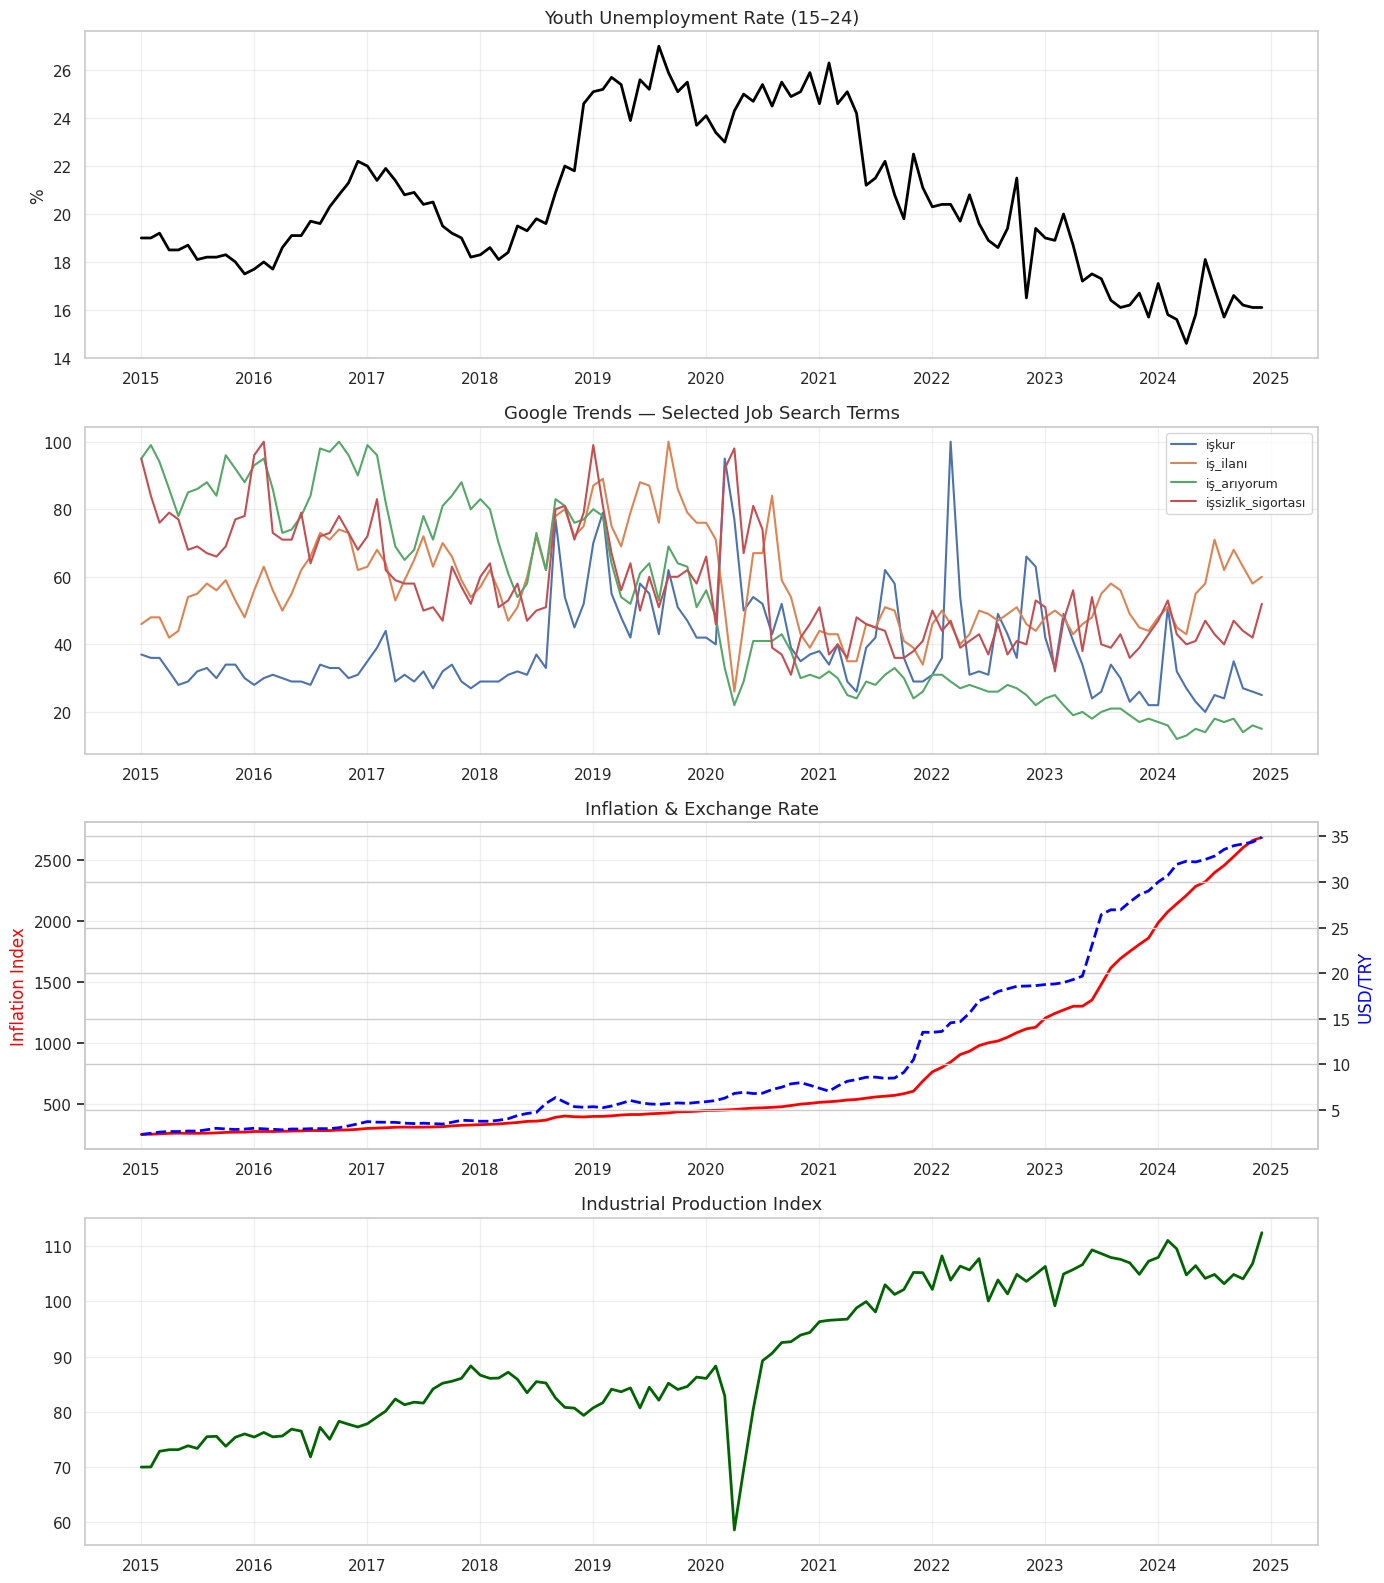

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

axes[0].plot(df_final['date'], df_final['youth_unemployment_rate'], color='black', linewidth=2)
axes[0].set_title('Youth Unemployment Rate (15–24)', fontsize=13)
axes[0].set_ylabel('%')

for col in ['işkur', 'iş_ilanı', 'iş_arıyorum', 'işsizlik_sigortası']:
    axes[1].plot(df_final['date'], df_final[col], label=col, linewidth=1.5)
axes[1].set_title('Google Trends — Selected Job Search Terms', fontsize=13)
axes[1].legend(fontsize=9)

axRight = axes[2].twinx()
axes[2].plot(df_final['date'], df_final['inflation'], color='red', label='Inflation Index', linewidth=2)
axRight.plot(df_final['date'], df_final['usd_try'], color='blue', label='USD/TRY', linewidth=2, linestyle='--')
axes[2].set_title('Inflation & Exchange Rate', fontsize=13)
axes[2].set_ylabel('Inflation Index', color='red')
axRight.set_ylabel('USD/TRY', color='blue')

axes[3].plot(df_final['date'], df_final['industrial_production'], color='darkgreen', linewidth=2)
axes[3].set_title('Industrial Production Index', fontsize=13)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Correlation Matrix

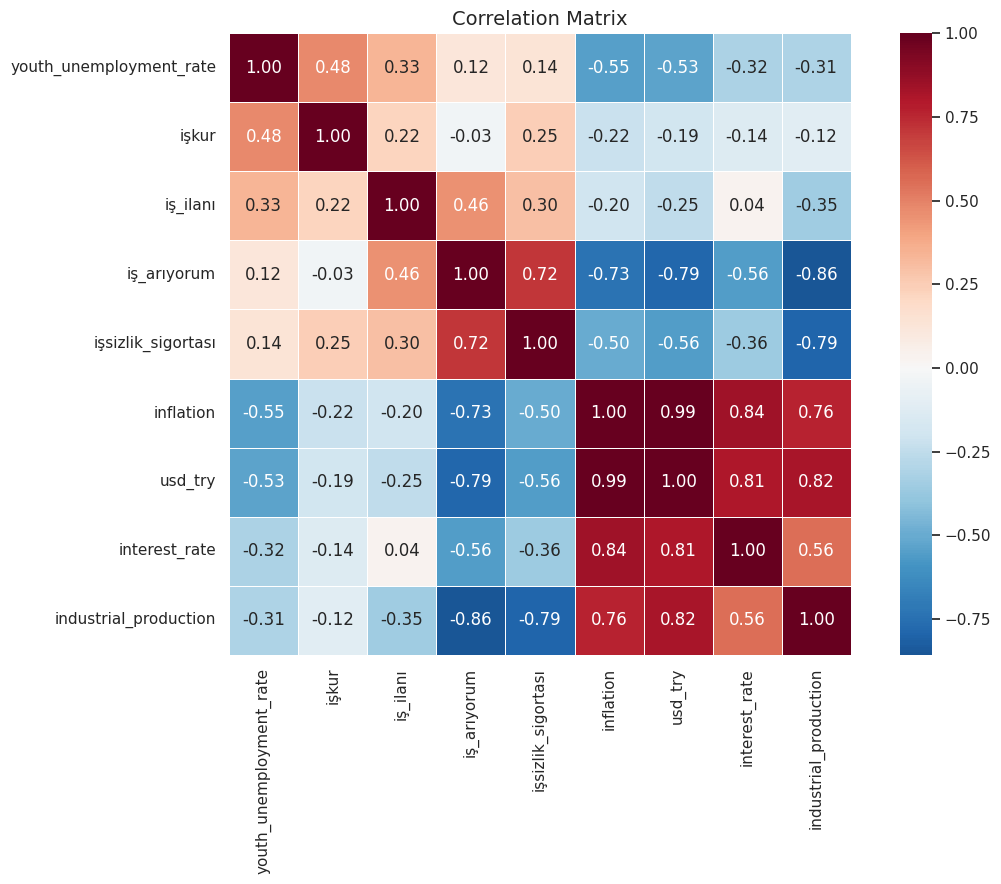

In [ ]:
corr_cols = [
    'youth_unemployment_rate', 'işkur', 'iş_ilanı', 'iş_arıyorum',
    'işsizlik_sigortası', 'inflation', 'usd_try', 'interest_rate', 'industrial_production'
]

corr = df_final[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Hypothesis Testing

**Research question:** Does a spike in job-related Google searches predict a rise in youth unemployment in Turkey, and if so, by how many months?

### 3.1 Cross-Correlation Analysis

We compute Pearson correlation between each search term and youth unemployment at lags (Months Ahead Before Official Data)
 0–6 months. A positive correlation at lag k means the search term predicts unemployment k months later.

In [ ]:
all_terms = [ 'işkur', 'iş_ilanı', 'iş_arıyorum', 'linkedin', 'kariyer_net',
    'iş_kurumu', 'cv_hazırlama', 'işsizlik_maaşı', 'işsizlik_sigortası', 'işsizlik_ödeneği'
]

target = df_final['youth_unemployment_rate']

print("Cross-correlations with youth_unemployment_rate:\n")
print(f"{'Term':<25} {'Lag 0':>8} {'Lag 1':>8} {'Lag 2':>8} {'Lag 3':>8} {'Lag 4':>8} {'Lag 5':>8} {'Lag 6':>8}")
print("-" * 85)

for col in all_terms:
    series = df_final[col]
    delayARR= []
    for delay in range(7):
        if delay == 0:
            r, p = stats.pearsonr(series, target)
        else:
            r, p = stats.pearsonr(series[:-delay], target[delay:])
        delayARR.append(f"{r:.2f}{'*' if p < 0.05 else ''}")
    print(f"{col:<25} {delayARR[0]:>8} {delayARR[1]:>8} {delayARR[2]:>8} {delayARR[3]:>8} {delayARR[4]:>8} {delayARR[5]:>8} {delayARR[6]:>8}")

print("\n* = p < 0.05")

Cross-correlations with youth_unemployment_rate:

Term                         Lag 0    Lag 1    Lag 2    Lag 3    Lag 4    Lag 5    Lag 6
-------------------------------------------------------------------------------------
işkur                        0.48*    0.52*    0.54*    0.52*    0.52*    0.48*    0.48*
iş_ilanı                     0.33*    0.37*    0.40*    0.43*    0.48*    0.49*    0.53*
iş_arıyorum                   0.12     0.14     0.16     0.17    0.19*    0.21*    0.23*
linkedin                    -0.44*   -0.45*   -0.47*   -0.48*   -0.49*   -0.52*   -0.52*
kariyer_net                   0.11     0.11     0.11     0.10     0.11     0.12     0.14
iş_kurumu                    0.21*    0.26*    0.32*    0.36*    0.39*    0.38*    0.42*
cv_hazırlama                -0.22*   -0.24*   -0.25*   -0.27*   -0.28*   -0.30*   -0.32*
işsizlik_maaşı               0.19*    0.26*    0.28*    0.30*    0.32*    0.33*    0.35*
işsizlik_sigortası            0.14     0.17    0.20*    0.24*  

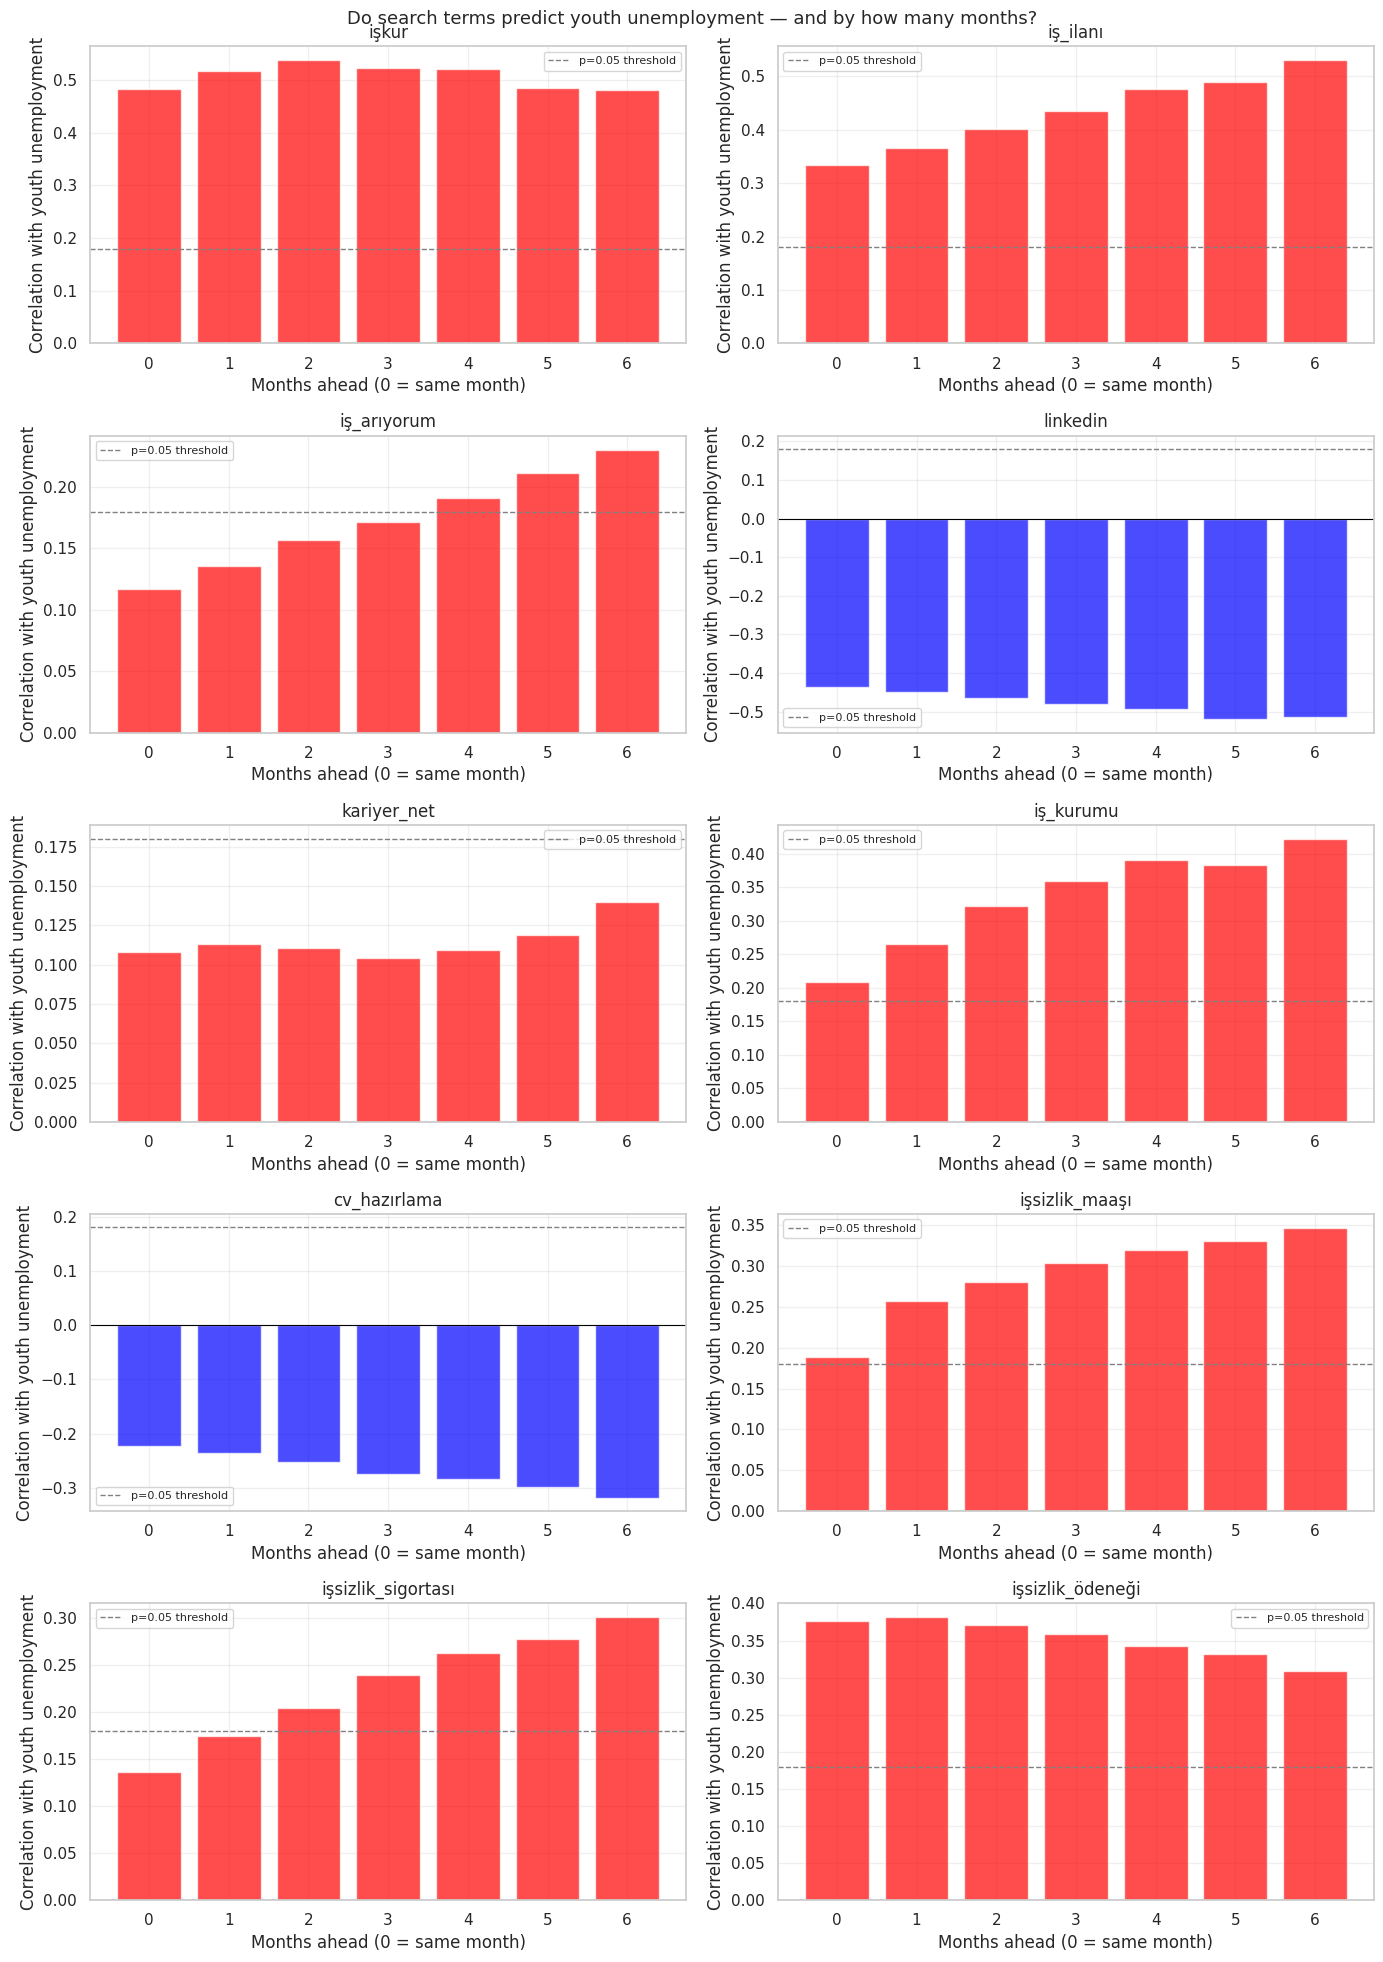

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(all_terms):
    delayARR = range(7)
    corrs = []
    for delay in delayARR:
        if delay== 0:
            r, _ = stats.pearsonr(df_final[col], df_final['youth_unemployment_rate'])
        else:
            r, _ = stats.pearsonr(df_final[col][:-delay], df_final['youth_unemployment_rate'][delay:])
        corrs.append(r)

    axes[i].bar(delayARR, corrs, color=['red' if c > 0 else 'blue' for c in corrs], alpha=0.7)

    axes[i].axhline(y=0, color='black', linewidth=0.8)
    axes[i].axhline(y=0.18, color='gray', linewidth=1, linestyle='--', label='p=0.05 threshold')

    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Months ahead (0 = same month)')
    axes[i].set_ylabel('Correlation with youth unemployment')

    axes[i].set_xticks(delayARR)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Do search terms predict youth unemployment — and by how many months?', fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 Independent Samples T-test

We split months into two groups based on search volume (above/below median) and test whether youth unemployment 2 months later differs significantly between the groups.

- **H₀:** Mean unemployment is the same in high and low search volume months
- **H₁:** Mean unemployment is higher when search volume is high

In [ ]:
print("T-test Results: High vs Low Search Volume Months (Months ahead = 2)\n")
print(f"{'Term':<25} {'High mean':>10} {'Low mean':>10} {'t-stat':>8} {'p-value':>10} {'Significant':>12}")
print("-" * 80)

for col in ['işkur', 'iş_ilanı', 'iş_arıyorum', 'işsizlik_sigortası','işsizlik_ödeneği']:
    search = df_final[col][:-2].values
    unemployment = df_final['youth_unemployment_rate'][2:].values

    median = np.median(search)
    high_group = unemployment[search >= median]
    low_group  = unemployment[search < median]

    t_stat, p_value = stats.ttest_ind(high_group, low_group)
    significant = "Yes *" if p_value < 0.05 else "No"

    print(f"{col:<25} {high_group.mean():>10.2f} {low_group.mean():>10.2f} {t_stat:>8.3f} {p_value:>10.4f} {significant:>12}")

print("\n* = statistically significant at p < 0.05")
print("Note: Search volume at month t compared to unemployment at month t+2")

T-test Results: High vs Low Search Volume Months (Months ahead = 2)

Term                       High mean   Low mean   t-stat    p-value  Significant
--------------------------------------------------------------------------------
işkur                          22.04      18.75    6.722     0.0000        Yes *
iş_ilanı                       21.02      19.87    2.035     0.0441        Yes *
iş_arıyorum                    20.82      20.13    1.213     0.2277           No
işsizlik_sigortası             20.99      19.95    1.832     0.0695           No
işsizlik_ödeneği               20.74      20.11    1.087     0.2791           No

* = statistically significant at p < 0.05
Note: Search volume at month t compared to unemployment at month t+2


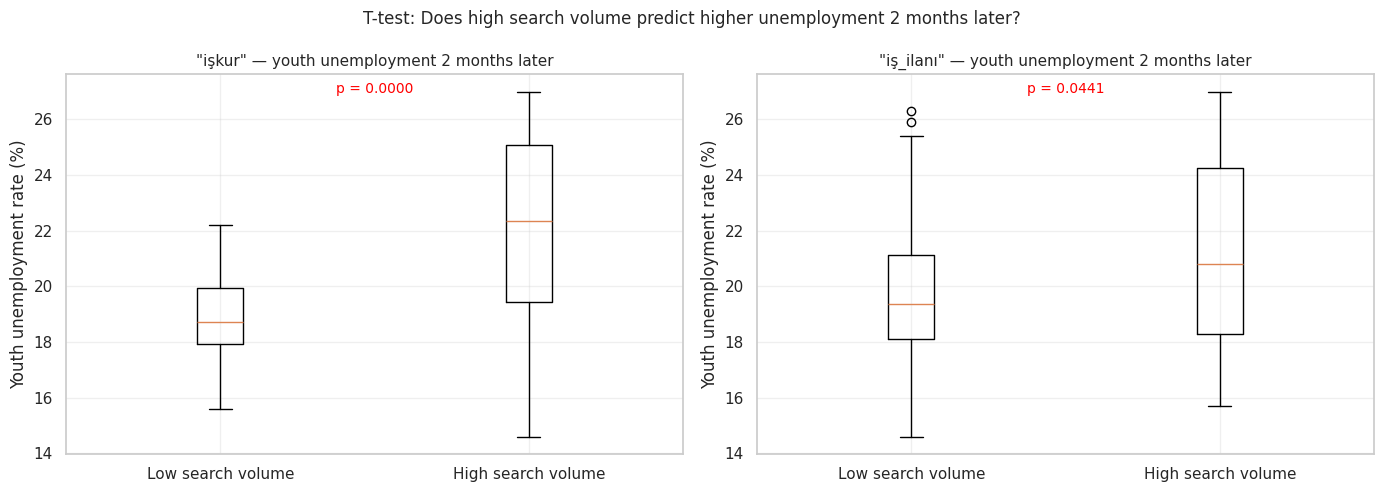

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['işkur', 'iş_ilanı']):
    search =df_final[col][:-2].values
    unemployment =df_final['youth_unemployment_rate'][2:].values

    median = np.median(search)
    high_group= unemployment[search >= median]
    low_group  = unemployment[search < median]

    axes[i].boxplot([low_group, high_group], labels=['Low search volume', 'High search volume'])
    axes[i].set_title(f'"{col}" — youth unemployment 2 months later', fontsize=11)
    axes[i].set_ylabel('Youth unemployment rate (%)')
    axes[i].grid(True, alpha=0.3)

    t_stat, p_value = stats.ttest_ind(high_group, low_group)
    axes[i].text(0.5, 0.95, f'p = {p_value:.4f}', transform=axes[i].transAxes,
                   ha='center', fontsize=10, color='red')

plt.suptitle('T-test: Does high search volume predict higher unemployment 2 months later?', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Summary of Findings

**Cross-correlation:**
- `işkur` shows the strongest and most consistent signal: correlation peaks at lag 2 (Months Ahead) (r = 0.54, p < 0.05)
- `iş_ilanı` also shows a growing correlation with lag, peaking at lag 3 (r = 0.43)
- `linkedin` and `cv_hazırlama` show negative correlations — these terms are searched more when the economy is doing well
- `iş_arıyorum` shows no statistically significant relationship

**T-test:**
- When `işkur` search volume is high, youth unemployment 2 months later averages 22.0% vs 18.7% when search volume is low (t = 6.90, p < 0.001)
- `iş_ilanı` also shows a significant difference (p = 0.044)

**Conclusion:** Search data — particularly `işkur` — predicts youth unemployment approximately 2 months in advance.